In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "../data/cleaned_online_retail.csv"
)

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [3]:
segments = pd.read_csv(
    "../data/customer_segments.csv"
)

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [5]:
segments.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,3,Loyal Customers
1,12347.0,2,7,4310.00,0,Regular Customers
2,12348.0,75,4,1797.24,0,Regular Customers
3,12349.0,19,1,1757.55,0,Regular Customers
4,12350.0,310,1,334.40,1,Lost Customers


In [6]:
recommendation_df = pd.merge(
    df,
    segments[
        [
            "CustomerID",
            "Segment"
        ]
    ],
    on="CustomerID",
    how="left"
)

In [7]:
recommendation_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,Loyal Customers
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Loyal Customers
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Loyal Customers
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Loyal Customers
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Loyal Customers


SECTION 1
Overall Best Selling Products

In [8]:
top_products = (
    recommendation_df
    .groupby("Description")
    .agg({
        "Quantity":"sum",
        "Revenue":"sum"
    })
    .sort_values(
        "Quantity",
        ascending=False
    )
)

top_products.head(20)

,Quantity,Revenue
Description,,
"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319,13558.41
JUMBO BAG RED RETROSPOT,46078,85040.54
WHITE HANGING HEART T-LIGHT HOLDER,36706,100392.10
ASSORTED COLOUR BIRD ORNAMENT,35263,56413.03
PACK OF 72 RETROSPOT CAKE CASES,33670,16381.88
POPCORN HOLDER,30919,23417.51
RABBIT NIGHT LIGHT,27153,51251.24


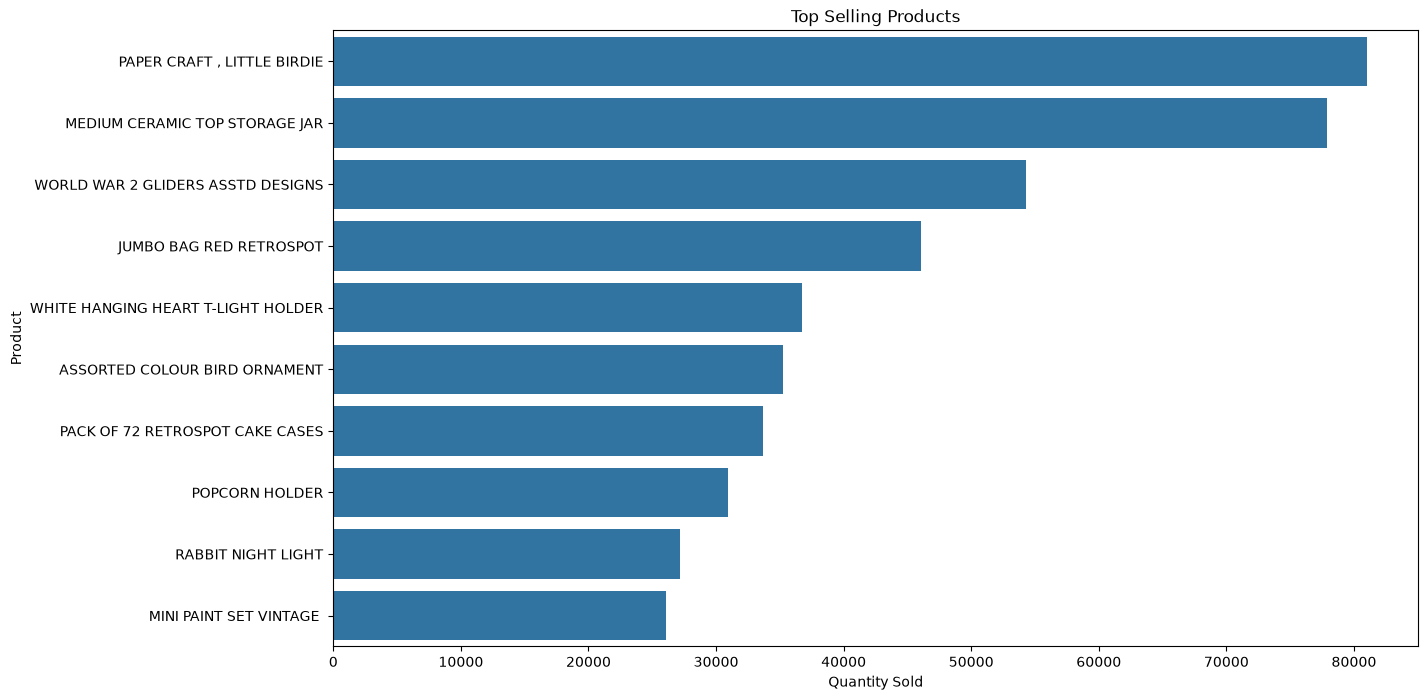

In [9]:
plt.figure(figsize=(14,8))

sns.barplot(
    x=top_products.head(10)["Quantity"],
    y=top_products.head(10).index
)

plt.title(
    "Top Selling Products"
)

plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.show()

SECTION 2
Highest Revenue Products

In [10]:
top_revenue_products = (
    recommendation_df
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

top_revenue_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

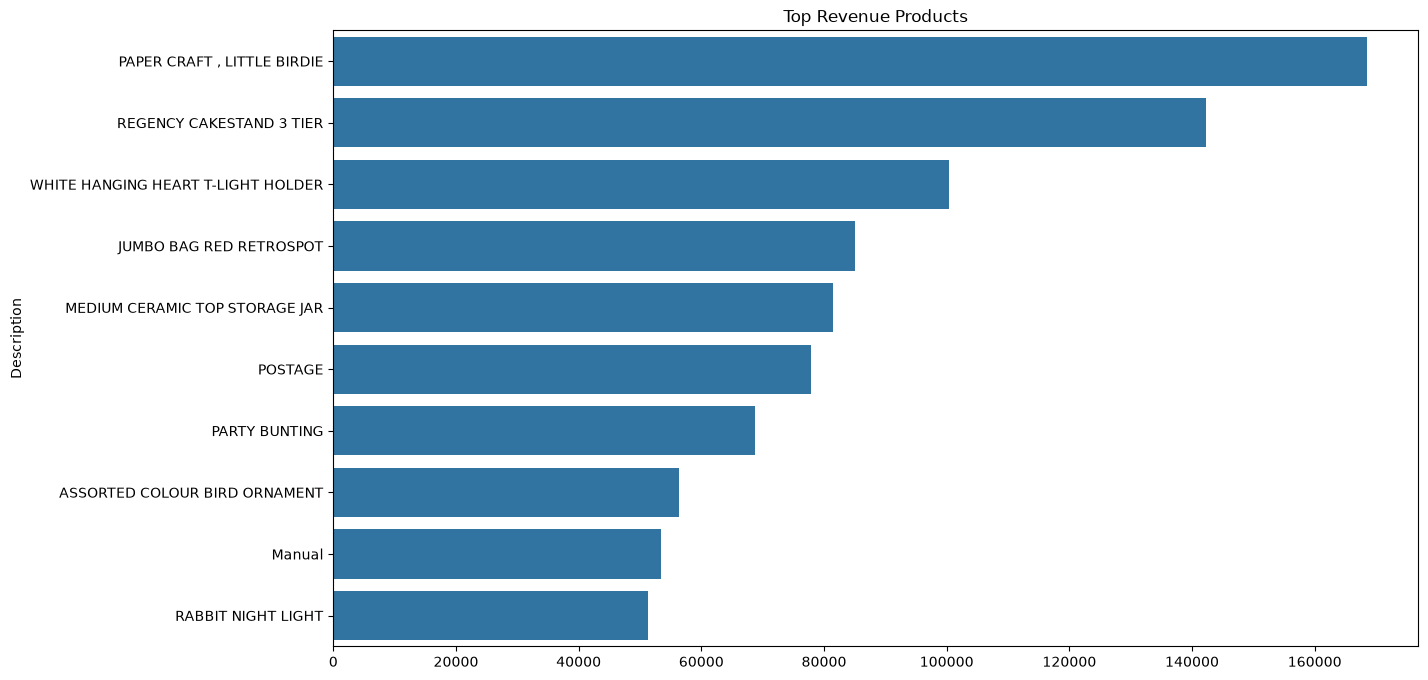

In [11]:
plt.figure(figsize=(14,8))

sns.barplot(
    x=top_revenue_products.head(10).values,
    y=top_revenue_products.head(10).index
)

plt.title(
    "Top Revenue Products"
)

plt.show()

SECTION 3
Segment-Based Recommendations

In [12]:
segment_products = (
    recommendation_df
    .groupby(
        [
            "Segment",
            "Description"
        ]
    )
    ["Quantity"]
    .sum()
    .reset_index()
)

In [13]:
for segment in recommendation_df[
    "Segment"
].unique():

    print(
        "\n",
        "="*50
    )

    print(segment)

    print("="*50)

    top_items = (
        segment_products[
            segment_products[
                "Segment"
            ] == segment
        ]
        .sort_values(
            "Quantity",
            ascending=False
        )
        .head(10)
    )

    print(
        top_items[
            [
                "Description",
                "Quantity"
            ]
        ]
    )


Loyal Customers
                             Description  Quantity
5932      MEDIUM CERAMIC TOP STORAGE JAR     75165
7451   WORLD WAR 2 GLIDERS ASSTD DESIGNS     25597
5737             JUMBO BAG RED RETROSPOT     20951
6425                      POPCORN HOLDER     19948
6128          PACK OF 12 LONDON TISSUES      15547
7376  WHITE HANGING HEART T-LIGHT HOLDER     15311
4451       ASSORTED COLOUR BIRD ORNAMENT     15139
4709                 BROCADE RING PURSE      11322
6485              RED  HARMONICA IN BOX      11256
6160  PACK OF 60 PINK PAISLEY CAKE CASES     11145

Regular Customers
                              Description  Quantity
11135   WORLD WAR 2 GLIDERS ASSTD DESIGNS     22097
9193              JUMBO BAG RED RETROSPOT     18078
9680      PACK OF 72 RETROSPOT CAKE CASES     16616
7730        ASSORTED COLOUR BIRD ORNAMENT     16591
11051  WHITE HANGING HEART T-LIGHT HOLDER     13241
10608         SMALL CHINESE STYLE SCISSOR     13084
10036                  RABBIT NIGHT LIG

SECTION 4
Country-Based Recommendations

In [14]:
country_products = (
    recommendation_df
    .groupby(
        [
            "Country",
            "Description"
        ]
    )
    ["Quantity"]
    .sum()
    .reset_index()
)

In [15]:
country = "United Kingdom"

country_products[
    country_products[
        "Country"
    ] == country
].sort_values(
    "Quantity",
    ascending=False
).head(10)

,Country,Description,Quantity
17562,United Kingdom,"PAPER CRAFT , LITTLE BIRDIE",80995
17239,United Kingdom,MEDIUM CERAMIC TOP STORAGE JAR,76919
19017,United Kingdom,WORLD WAR 2 GLIDERS ASSTD DESIGNS,49086
17011,United Kingdom,JUMBO BAG RED RETROSPOT,41878
18930,United Kingdom,WHITE HANGING HEART T-LIGHT HOLDER,34630
15477,United Kingdom,ASSORTED COLOUR BIRD ORNAMENT,32628
17838,United Kingdom,POPCORN HOLDER,28923
17478,United Kingdom,PACK OF 12 LONDON TISSUES,24321
15799,United Kingdom,BROCADE RING PURSE,22675
17512,United Kingdom,PACK OF 72 RETROSPOT CAKE CASES,22442


SECTION 5
Customer Purchase History

In [16]:
customer_products = (
    recommendation_df
    .groupby(
        [
            "CustomerID",
            "Description"
        ]
    )
    ["Quantity"]
    .sum()
    .reset_index()
)

In [17]:
customer_id = 14646

In [18]:
customer_products[
    customer_products[
        "CustomerID"
    ] == customer_id
].sort_values(
    "Quantity",
    ascending=False
).head(20)

,CustomerID,Description,Quantity
105673,14646.0,RABBIT NIGHT LIGHT,4801
105848,14646.0,SPACEBOY LUNCH BOX,4492
105601,14646.0,PACK OF 72 RETROSPOT CAKE CASES,4104
105366,14646.0,DOLLY GIRL LUNCH BOX,4096
105738,14646.0,ROUND SNACK BOXES SET OF4 WOODLAND,3120
105708,14646.0,RED TOADSTOOL LED NIGHT LIGHT,2376
105900,14646.0,WOODLAND CHARLOTTE BAG,2300
105692,14646.0,RED RETROSPOT CHARLOTTE BAG,2100
105234,14646.0,5 HOOK HANGER RED MAGIC TOADSTOOL,2016
105499,14646.0,JUMBO BAG RED RETROSPOT,2000


SECTION 6
Recommendation Function

In [19]:
def recommend_products(
    segment,
    n=10
):

    recommendations = (
        segment_products[
            segment_products[
                "Segment"
            ] == segment
        ]
        .sort_values(
            "Quantity",
            ascending=False
        )
        .head(n)
    )

    return recommendations[
        [
            "Description",
            "Quantity"
        ]
    ]

In [20]:
recommend_products(
    "Elite Customers"
)

,Description,Quantity


SECTION 7
Save Recommendation Tables

In [21]:
segment_products.to_csv(
    "../data/segment_recommendations.csv",
    index=False
)

In [22]:
top_products.to_csv(
    "../data/top_products.csv"
)

In [28]:
top_products.to_csv(
    "../data/top_products.csv"
)

In [23]:
customer_products.to_csv(
    "../data/customer_products.csv",
    index=False
)

SECTION 8

Country Based Recommendations

In [24]:
country_products = (
    recommendation_df
    .groupby(
        ["Country", "Description"]
    )["Quantity"]
    .sum()
    .reset_index()
)

In [25]:
country_products.head()

,Country,Description,Quantity
0,Australia,DOLLY GIRL BEAKER,200
1,Australia,I LOVE LONDON MINI BACKPACK,4
2,Australia,10 COLOUR SPACEBOY PEN,48
3,Australia,12 PENCIL SMALL TUBE WOODLAND,384
4,Australia,12 PENCILS TALL TUBE POSY,252


In [26]:
country = "United Kingdom"

country_products[
    country_products["Country"]
    == country
].sort_values(
    "Quantity",
    ascending=False
).head(10)

,Country,Description,Quantity
17562,United Kingdom,"PAPER CRAFT , LITTLE BIRDIE",80995
17239,United Kingdom,MEDIUM CERAMIC TOP STORAGE JAR,76919
19017,United Kingdom,WORLD WAR 2 GLIDERS ASSTD DESIGNS,49086
17011,United Kingdom,JUMBO BAG RED RETROSPOT,41878
18930,United Kingdom,WHITE HANGING HEART T-LIGHT HOLDER,34630
15477,United Kingdom,ASSORTED COLOUR BIRD ORNAMENT,32628
17838,United Kingdom,POPCORN HOLDER,28923
17478,United Kingdom,PACK OF 12 LONDON TISSUES,24321
15799,United Kingdom,BROCADE RING PURSE,22675
17512,United Kingdom,PACK OF 72 RETROSPOT CAKE CASES,22442


In [27]:
country_products.to_csv(
    "../data/country_recommendations.csv",
    index=False
)

SECTION 9

Collaborative Filtering Model

In [29]:
from sklearn.metrics.pairwise import cosine_similarity
import joblib

In [30]:
product_matrix = recommendation_df.pivot_table(
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

product_matrix.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
product_matrix_t = product_matrix.T

product_matrix_t.head()

CustomerID,12346.0,12347.0,12348.0,12349.0,12350.0,12352.0,12353.0,12354.0,12355.0,12356.0,...,18273.0,18274.0,18276.0,18277.0,18278.0,18280.0,18281.0,18282.0,18283.0,18287.0
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
50'S CHRISTMAS GIFT BAG LARGE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DOLLY GIRL BEAKER,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
I LOVE LONDON MINI BACKPACK,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
I LOVE LONDON MINI RUCKSACK,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
similarity_matrix = cosine_similarity(
    product_matrix_t
)

In [33]:
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=product_matrix_t.index,
    columns=product_matrix_t.index
)

similarity_df.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000021,0.000228,0.000000,0.000000,0.020228,0.000000,0.000263,0.063543,...,0.0,0.001376,0.015917,0.001771,0.0,0.002852,0.0,0.013155,0.000000,0.002599
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.003534,0.004001,0.000000,0.020230,0.027477,0.902593,0.119038,0.013384,...,0.0,0.001726,0.015572,0.018032,0.0,0.015710,0.0,0.011238,0.000000,0.029793
DOLLY GIRL BEAKER,0.000021,0.003534,1.000000,0.870965,0.980574,0.006358,0.005311,0.003040,0.001764,0.411471,...,0.0,0.000044,0.002869,0.344928,0.0,0.525868,0.0,0.822964,0.000097,0.006665
I LOVE LONDON MINI BACKPACK,0.000228,0.004001,0.870965,1.000000,0.883987,0.020076,0.004912,0.004051,0.008249,0.382226,...,0.0,0.001416,0.004198,0.310053,0.0,0.471772,0.0,0.749303,0.000000,0.010394
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.980574,0.883987,1.000000,0.000000,0.000000,0.000000,0.000000,0.410712,...,0.0,0.000000,0.000000,0.347021,0.0,0.530836,0.0,0.837176,0.000000,0.000000


In [34]:
joblib.dump(
    similarity_df,
    "../models/similarity_matrix.pkl"
)

['../models/similarity_matrix.pkl']